# Synthetic Oligo Model Anaylsis - Test Polymerases 

## Preprocessing
- Run *RETrace2/scripts/fastq_microsatellite_extractor.py* to extract microsatellite from fastq.gz to get the result.tsv

```bash
#!/bin/bash
for file in /home/tcheng/Projects/RETrace/20220724_MiSeq_Oligo_6polymerase/0_Raw_Read/Fastq/*.fastq.gz; do
    if [ -f "$file" ]; then
        echo "Processing: $(basename "$file")"
        python /home/tcheng/software/RETrace2/scripts/fastq_microsatellite_extractor.py "$file" ./
        echo "Completed: $(basename "$file")"
        echo "---"
    else
        echo "No .fastq.gz files found in the directory"
    fi
done

echo "All files processed!"
```


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns
from tqdm import tqdm
from scipy.stats import mannwhitneyu

In [2]:
# check filename
import glob
glob.glob("../1_Read/Oligo*")

['../1_Read/Oligo_Kapa_202207024_set1_S1_L001_R1_001_result.tsv',
 '../1_Read/Oligo_Q5_202207024_set1_S2_L001_R1_001_result.tsv',
 '../1_Read/Oligo_PrimeSTAR_202207024_set1_S4_L001_R1_001_result.tsv',
 '../1_Read/Oligo_SeqAMP_202207024_set1_S3_L001_R1_001_result.tsv']

In [3]:
# custom order
path_ls = ['../1_Read/Oligo_Kapa_202207024_set1_S1_L001_R1_001_result.tsv',
           '../1_Read/Oligo_Q5_202207024_set1_S2_L001_R1_001_result.tsv',
           '../1_Read/Oligo_SeqAMP_202207024_set1_S3_L001_R1_001_result.tsv',
           '../1_Read/Oligo_PrimeSTAR_202207024_set1_S4_L001_R1_001_result.tsv']

# put name order same as path
fname_ls = ['Kapa', 'Q5', 'SeqAMP', 'PrimeSTAR'] 

# Stats

## n_read

In [4]:
result_ls = [pd.read_csv(path, sep='\t') for path in path_ls]

In [5]:
# check result df
result_ls[3].head(10)

,read,umi,lib,ms
0,TANATTATCGTCGAATTACAGACCTTATGGAATTGGACACAATACC...,ATTATCGTCGAATTACAGAC,CTTATGGAAT,ACACACACACACACACACAC
1,TANTGCTAAGATCGGGTATAAAACGCTCAGTTCGGGGTTCTGCTTT...,TGCTAAGATCGGGTATAAAA,CGCTCAGTTC,AAAAAAAAAAAAAAAA
2,TANTTGTCGCAGCTATCGGGATGTAATCTCGTCAAGTGACAGCTAT...,TTGTCGCAGCTATCGGGATG,TAATCTCGTC,ACACACACACACACACACACACACACACAC
3,TANGATGTAGTGCTTAGTATCGTCTTATGGCATTGGACACAATACC...,GATGTAGTGCTTAGTATCGT,CTTATGGCAT,NaN
4,TANTTCTCGAGAGAAGTGGATGTCGCTCAGTTCGGGGTTCTGCTTT...,TTCTCGAGAGAAGTGGATGT,CGCTCAGTTC,AAAAAAAAAAAA
5,TANGGAGCGAGGATCATTGGTCCTATCTGACCTGATTGTGCCACTG...,GGAGCGAGGATCATTGGTCC,TATCTGACCT,AAAAAAAAAAAAAAAAAA
6,TANTCGTTCAATCGACCTTAGTCCGCTCAGTTCGGGGTTCTGCTTT...,TCGTTCAATCGACCTTAGTC,CGCTCAGTTC,AAAAAAAAAAAAA
7,TANTGATTGAAGTGGGAGTTAGGATATGAGACGAGCTAAGATTGTA...,TGATTGAAGTGGGAGTTAGG,ATATGAGACG,AAAAAAAAA
8,TANTGGGTTTGCAAGGCCCTTCTTATCTGCCCTGATTGTGCCCCTT...,TGGGTTTGCAAGGCCCTTCT,TATCTGCCCT,NaN
9,TANATAGGTGGATTTTGGTGATACGCTCAGTTCGGGGTTCTGCTTT...,ATAGGTGGATTTTGGTGATA,CGCTCAGTTC,AAAAAAAAAAAAAA


In [6]:
for i, result in enumerate(result_ls):
    n_total = result.shape[0]
    print(f'{fname_ls[i]}: Total num of reads: {n_total}')

Kapa: Total num of reads: 4675128
Q5: Total num of reads: 3273555
SeqAMP: Total num of reads: 3214268
PrimeSTAR: Total num of reads: 3399983


## % total match library index
- Based on olgio synthesis error rate, this should be ~80 to 90%

In [7]:
# check library index count
result_ls[3]['lib'].value_counts()[:10]

lib
CGCTCAGTTC    1092958
TATCTGACCT     877030
ATATGAGACG     510776
CTTATGGAAT     391710
TAATCTCGTC     390731
CTTATGGACT      11317
GCTCAGTTCG       8306
ATCTGACCTG       6607
TACTCTCGTC       6044
ATCTGAGACG       4029
Name: count, dtype: int64

In [8]:
# accurate library index vs ms match
lib_to_ms = {'CGCTCAGTTC': 'AAAAAAAAAAAAAAA', 'TATCTGACCT':'AAAAAAAAAAAAAAAAAAAA', 'ATATGAGACG':'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA',
               'CTTATGGAAT': 'ACACACACACACACACACAC', 'TAATCTCGTC': 'ACACACACACACACACACACACACACACAC'}

In [9]:
# count n pefect match known library index
for i, result in enumerate(result_ls):
    n_match = sum([lib in lib_to_ms.keys() for lib in result['lib']])
    n_total = result.shape[0]
    print(f'{fname_ls[i]}: %matach library index: {round(n_match/n_total*100,2)}%')

Kapa: %matach library index: 96.05%
Q5: %matach library index: 96.16%
SeqAMP: %matach library index: 95.67%
PrimeSTAR: %matach library index: 95.98%


## % total match MS sequence (no NA in MS col)
- expect only a few percentage decrease from % total match library index, indicating most MS sequence can be reg matched

In [10]:
for i, result in enumerate(result_ls):
    n_na = sum(result['ms'].isna())
    n_total = result.shape[0]
    print(f'{fname_ls[i]}: %match MS sequence: {round((n_total-n_na)/n_total*100,2)}%')

Kapa: %match MS sequence: 88.78%
Q5: %match MS sequence: 89.29%
SeqAMP: %match MS sequence: 89.42%
PrimeSTAR: %match MS sequence: 89.31%


- I think a potential reason all QC numbers are higher is becasue PCR single nucleotide errors are acutally significant!

## Depth coverage distribution (Before any filter!)
- This is to see if sequencing is deep enough, we want most >10 depth

In [11]:
# rough check %umi > ? depth, that is our criteria for evaluating accuracy, but there are some overlap umi between libraries
thres = 10

n_high_ls =[]
n_high_perc_ls = []

for i, result in enumerate(result_ls):
    umi_count = result['umi'].value_counts()
    n_high = sum(umi_count >= thres)
    n_high_perc = round(n_high/len(umi_count)*100, 2)
    
    n_high_ls.append(n_high)
    n_high_perc_ls.append(n_high_perc)
    
    print(f'{fname_ls[i]}: Num of umi >= {thres} depth: {n_high}/{len(umi_count)} ({n_high_perc}%)')

Kapa: Num of umi >= 10 depth: 136238/238653 (57.09%)
Q5: Num of umi >= 10 depth: 58910/117893 (49.97%)
SeqAMP: Num of umi >= 10 depth: 113181/187203 (60.46%)
PrimeSTAR: Num of umi >= 10 depth: 92390/152015 (60.78%)


/tmp/ipykernel_331372/1729709977.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10').colors


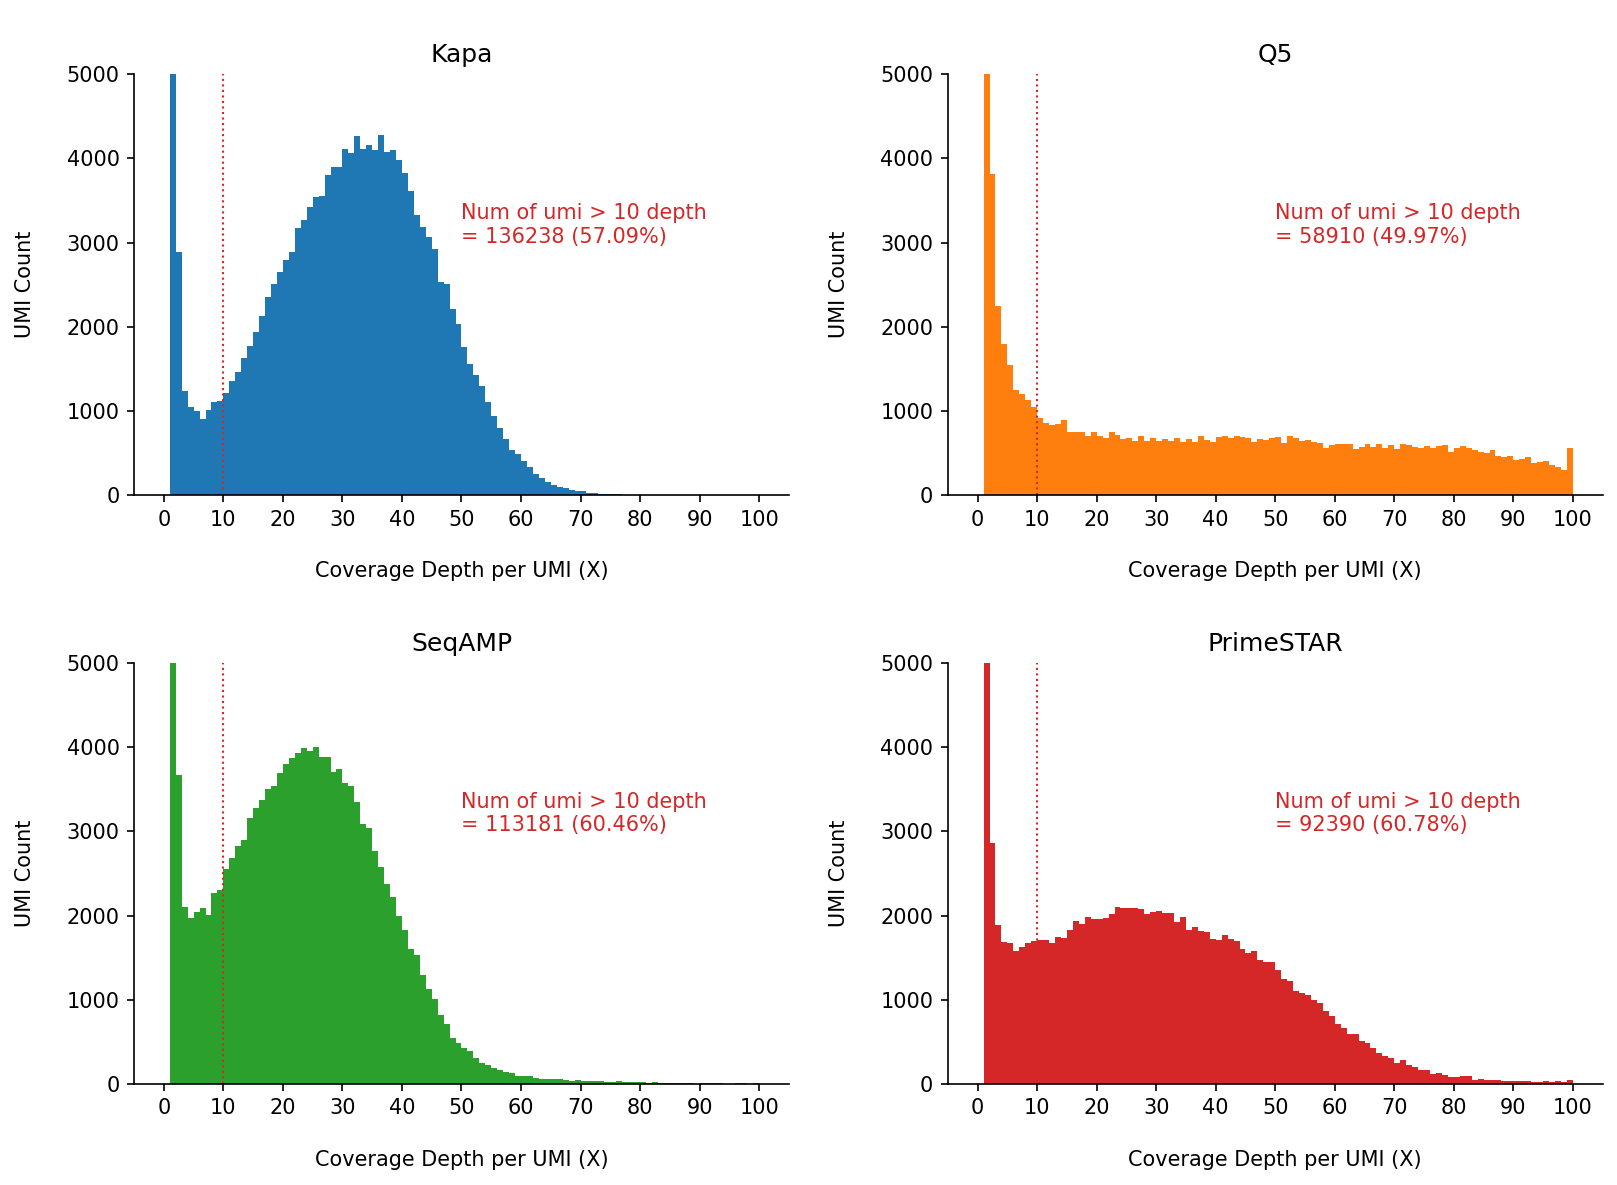

In [12]:
cmap = cm.get_cmap('tab10').colors
n= len(result_ls)
if n%2 == 0:
    nrow = int(n/2)
else:
    nrow = int(n/2)+1

fig, ax = plt.subplots(figsize=(11,4*nrow), dpi=150, ncols=2, nrows=nrow)

for i, result in enumerate(result_ls):
   
    # set ax index x,y
    x = int(i/2)
    y = i%2

    ax[x,y].hist(result['umi'].value_counts(), bins=100, range=(0,100), color=cmap[i])
    
    ax[x,y].set_xticks(np.arange(0,101,10))
    ax[x,y].set_title(f'\n{fname_ls[i]}')
    ax[x,y].set_xlabel("\nCoverage Depth per UMI (X)")
    ax[x,y].set_ylabel("UMI Count\n")

    ax[x,y].spines['right'].set_visible(False)
    ax[x,y].spines['top'].set_visible(False)

    ax[x,y].set_ylim(0,5000)
    ax[x,y].axvline(thres, c='tab:red', ls='dotted', linewidth=1)
    ax[x,y].text(50, 3000, f'Num of umi > {thres} depth\n= {n_high_ls[i]} ({n_high_perc_ls[i]}%)', c='tab:red')

plt.subplots_adjust(wspace=0.8, hspace=1)
plt.tight_layout()
plt.show()

- Interesting Q5 have a different distribution than others, but this is not ideal, becasue it means UMIs are unevenly amplified (have different coverage detph)
- The other 3 polymerase distribution looks better, with a bunch (peak) of UMIs more evenly amplified


# Oligo design perfect match with read seq
- this is usally ~30% (70% error is from oligo synthesis + pcr + sequencing error)

In [13]:
# filter library index, ms seq, 
filter_dc = {}
for i, result in enumerate(result_ls):
    
    # filter df with lib matches
    is_match = [lib in lib_to_ms.keys() for lib in result['lib']]
    filter_df = result.iloc[is_match,]
    
    # remove na in ms col, these are ones with library index match, but cannot find ms sequence
    filter_df = filter_df.dropna(subset=['ms'])
 
    filter_dc[fname_ls[i]] = filter_df

In [14]:
for exp, filter_df in filter_dc.items():
    # match
    match_ls = filter_df['lib'].map(lib_to_ms) == filter_df['ms']

    # percebt of perfect match (design oligo vs read seq)
    print(f'{exp}: %read with oligo design match ms seq: {round(sum(match_ls)/len(match_ls)*100,2)}%')  

Kapa: %read with oligo design match ms seq: 30.06%
Q5: %read with oligo design match ms seq: 40.78%
SeqAMP: %read with oligo design match ms seq: 39.0%
PrimeSTAR: %read with oligo design match ms seq: 37.94%


# Combined df and (optional) normalize read count across groups
- I dont think this matter much becasue we set a min coverage depth threshold, but to be safe.
- Ignore this if very few UMI per library

In [15]:
normalize = False

if normalize:
    # find min num of read among three library, normalize to this (not sure if sample size matters, just being careful...)
    min_read = min([filter_df.shape[0] for lib, filter_df in filter_dc.items()])
    min_read

    random_state = 1 
    # combine libraries into 1 df, downsample read, add n_cycle col
    filter_df_ls =[]
    for exp, filter_df in filter_dc.items():
        filter_df = filter_df.sample(n=min_read, random_state=random_state)
        filter_df['exp'] = exp
        filter_df_ls.append(filter_df)

    comb_df = pd.concat(filter_df_ls, ignore_index=True)  #ignore_index to reset index --> or get 3 replicate same index

else:
    filter_df_ls =[]
    for exp, filter_df in filter_dc.items():
        filter_df['exp'] = exp
        filter_df_ls.append(filter_df)

    comb_df = pd.concat(filter_df_ls, ignore_index=True)  #ignore_index to reset index --> or get 3 replicate same index

# Find most freqent n_repeat (mode)
- we will assume this is initial oligo sequence

In [16]:
# add library name from lib lindex
lib_to_name = {'CGCTCAGTTC': '15xA', 'TATCTGACCT':'20xA', 'ATATGAGACG':'30xA', 'CTTATGGAAT': '10xAC', 'TAATCTCGTC': '15xAC'}
comb_df['lib_name'] = [lib_to_name[lib] for lib in comb_df['lib']]

In [17]:
# combine cols for easier grouping, and bc umi can overlap between libraries
comb_df['umi_exp_libname'] = [f'{comb_df.umi[i]}_{comb_df.exp[i]}_{comb_df.lib_name[i]}' for i in tqdm(range(comb_df.shape[0]))]

100%|██████████| 12984231/12984231 [03:34<00:00, 60608.68it/s]


In [18]:
# filter only include umi > ? reads for analysis, use umi+lib+cycles bc some umi overlap...
print(f'Previous threshold set at: {thres}') # check previous thres setting

umi_count = comb_df['umi_exp_libname'].value_counts() 
is_high = umi_count >= thres
umi_high = umi_count.index[is_high]
print(f'%UMI pass > {thres} depth: {round(sum(is_high)/len(is_high)*100, 2)}%')

comb_df = comb_df[[x in umi_high for x in comb_df['umi_exp_libname']]]

Previous threshold set at: 10
%UMI pass > 10 depth: 61.85%


In [19]:
comb_df['len_ms'] = [len(ms) for ms in comb_df['ms']]

In [20]:
# extract top 1 most frequent repeat, assume this is initial oligo seq
umi_mode_sr = comb_df.groupby(by='umi_exp_libname')['len_ms'].agg(lambda x:x.value_counts().index[0])  
umi_to_mode = pd.DataFrame({'umi_exp_libname': umi_mode_sr.index, 'mode_len_ms': umi_mode_sr.values})
comb_df = pd.merge(comb_df, umi_to_mode, on='umi_exp_libname')

In [21]:
comb_df['nbase_to_mode'] = comb_df.len_ms - comb_df.mode_len_ms

In [22]:
comb_df.head(10)

,read,umi,lib,ms,exp,lib_name,umi_exp_libname,len_ms,mode_len_ms,nbase_to_mode
0,TAAGTGGGTATATATGGGTGTGACGCTCAGTTCGGGGTTCTGCTTT...,GTGGGTATATATGGGTGTGA,CGCTCAGTTC,AAAAAAAAAAAAAA,Kapa,15xA,GTGGGTATATATGGGTGTGA_Kapa_15xA,14,15,-1
1,TAACGTTATTTTATCACGGAGTACGCTCAGTTCGGGGTTCTGCTTT...,CGTTATTTTATCACGGAGTA,CGCTCAGTTC,AAAAAAAAAAAAAA,Kapa,15xA,CGTTATTTTATCACGGAGTA_Kapa_15xA,14,15,-1
2,TAAGGTTGTTATGCAAAACCCGTATATGAGACGAGCTAAGATTGTA...,GGTTGTTATGCAAAACCCGT,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAA,Kapa,30xA,GGTTGTTATGCAAAACCCGT_Kapa_30xA,29,30,-1
3,TAACGCCATTATGGATTCCATGTCGCTCAGTTCGGGGTTCTGCTTT...,CGCCATTATGGATTCCATGT,CGCTCAGTTC,AAAAAAAAAAAAAAA,Kapa,15xA,CGCCATTATGGATTCCATGT_Kapa_15xA,15,15,0
4,TAACAGAGACTGTCTTCTACTGATAATCTCGTCAAGTGACAGCTAT...,CAGAGACTGTCTTCTACTGA,TAATCTCGTC,ACACACACACACACACACACACACAC,Kapa,15xAC,CAGAGACTGTCTTCTACTGA_Kapa_15xAC,26,30,-4
5,TAAACGGGCTACTACTTATCCATCTTATGGAATTGGACACAATACC...,ACGGGCTACTACTTATCCAT,CTTATGGAAT,ACACACACACACACACACAC,Kapa,10xAC,ACGGGCTACTACTTATCCAT_Kapa_10xAC,20,20,0
6,TAAGAAACGCCCTTTGTCTAAGACGCTCAGTTCGGGGTTCTGCTTT...,GAAACGCCCTTTGTCTAAGA,CGCTCAGTTC,AAAAAAAAAAAAAAAA,Kapa,15xA,GAAACGCCCTTTGTCTAAGA_Kapa_15xA,16,15,1
7,TAAACAATATGGACGCGCTCATACGCTCAGTTCGGGGTTCTGCTTT...,ACAATATGGACGCGCTCATA,CGCTCAGTTC,AAAAAAAAAAAAAAAA,Kapa,15xA,ACAATATGGACGCGCTCATA_Kapa_15xA,16,15,1
8,TAATAATACAGTGTGCCTATGGTTATCTGACCTGATTGTGCCACTG...,TAATACAGTGTGCCTATGGT,TATCTGACCT,AAAAAAAAAAAAAAAAAA,Kapa,20xA,TAATACAGTGTGCCTATGGT_Kapa_20xA,18,18,0
9,TAAGAAAATAGTCATGGCATGCCATATGAGACGAGCTAAGCTTGTA...,GAAAATAGTCATGGCATGCC,ATATGAGACG,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA,Kapa,30xA,GAAAATAGTCATGGCATGCC_Kapa_30xA,30,32,-2


## Count table for exp and lib

In [23]:
# check count for each exp group after filter
comb_df['exp'].value_counts()

exp
Kapa         4026004
PrimeSTAR    2923674
Q5           2826685
SeqAMP       2731059
Name: count, dtype: int64

In [24]:
# check count for each lib_name
comb_df['lib_name'].value_counts()

lib_name
15xA     4461009
20xA     2896939
30xA     2284194
15xAC    1457752
10xAC    1407528
Name: count, dtype: int64

## Add ms_type (1nt vs 2nt)

In [25]:
ms_type = []
for lib in comb_df['lib']:
    if lib in ['CGCTCAGTTC', 'TATCTGACCT', 'ATATGAGACG']:
        ms_type.append(1) # 1nt repeat
        
    elif lib in ['CTTATGGAAT', 'TAATCTCGTC']:
        ms_type.append(2) # 2nt repeat
        
    else:
        print('no match library index!!!check!')
        break
        

In [26]:
comb_df['ms_type'] = ms_type

## Add n repeat to mode

In [27]:
comb_df['nrepeat_to_mode'] = (comb_df['nbase_to_mode']/comb_df['ms_type']).astype(int)

## Save comb_df

In [28]:
comb_df.to_csv('./comb_df.tsv', sep='\t', index=False)

# Plot dispersion, n_repeat from mode

/tmp/ipykernel_331372/981396700.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='exp', y='nrepeat_to_mode', data=comb_df, hue='lib_name', color='black', size=3, dodge=True,


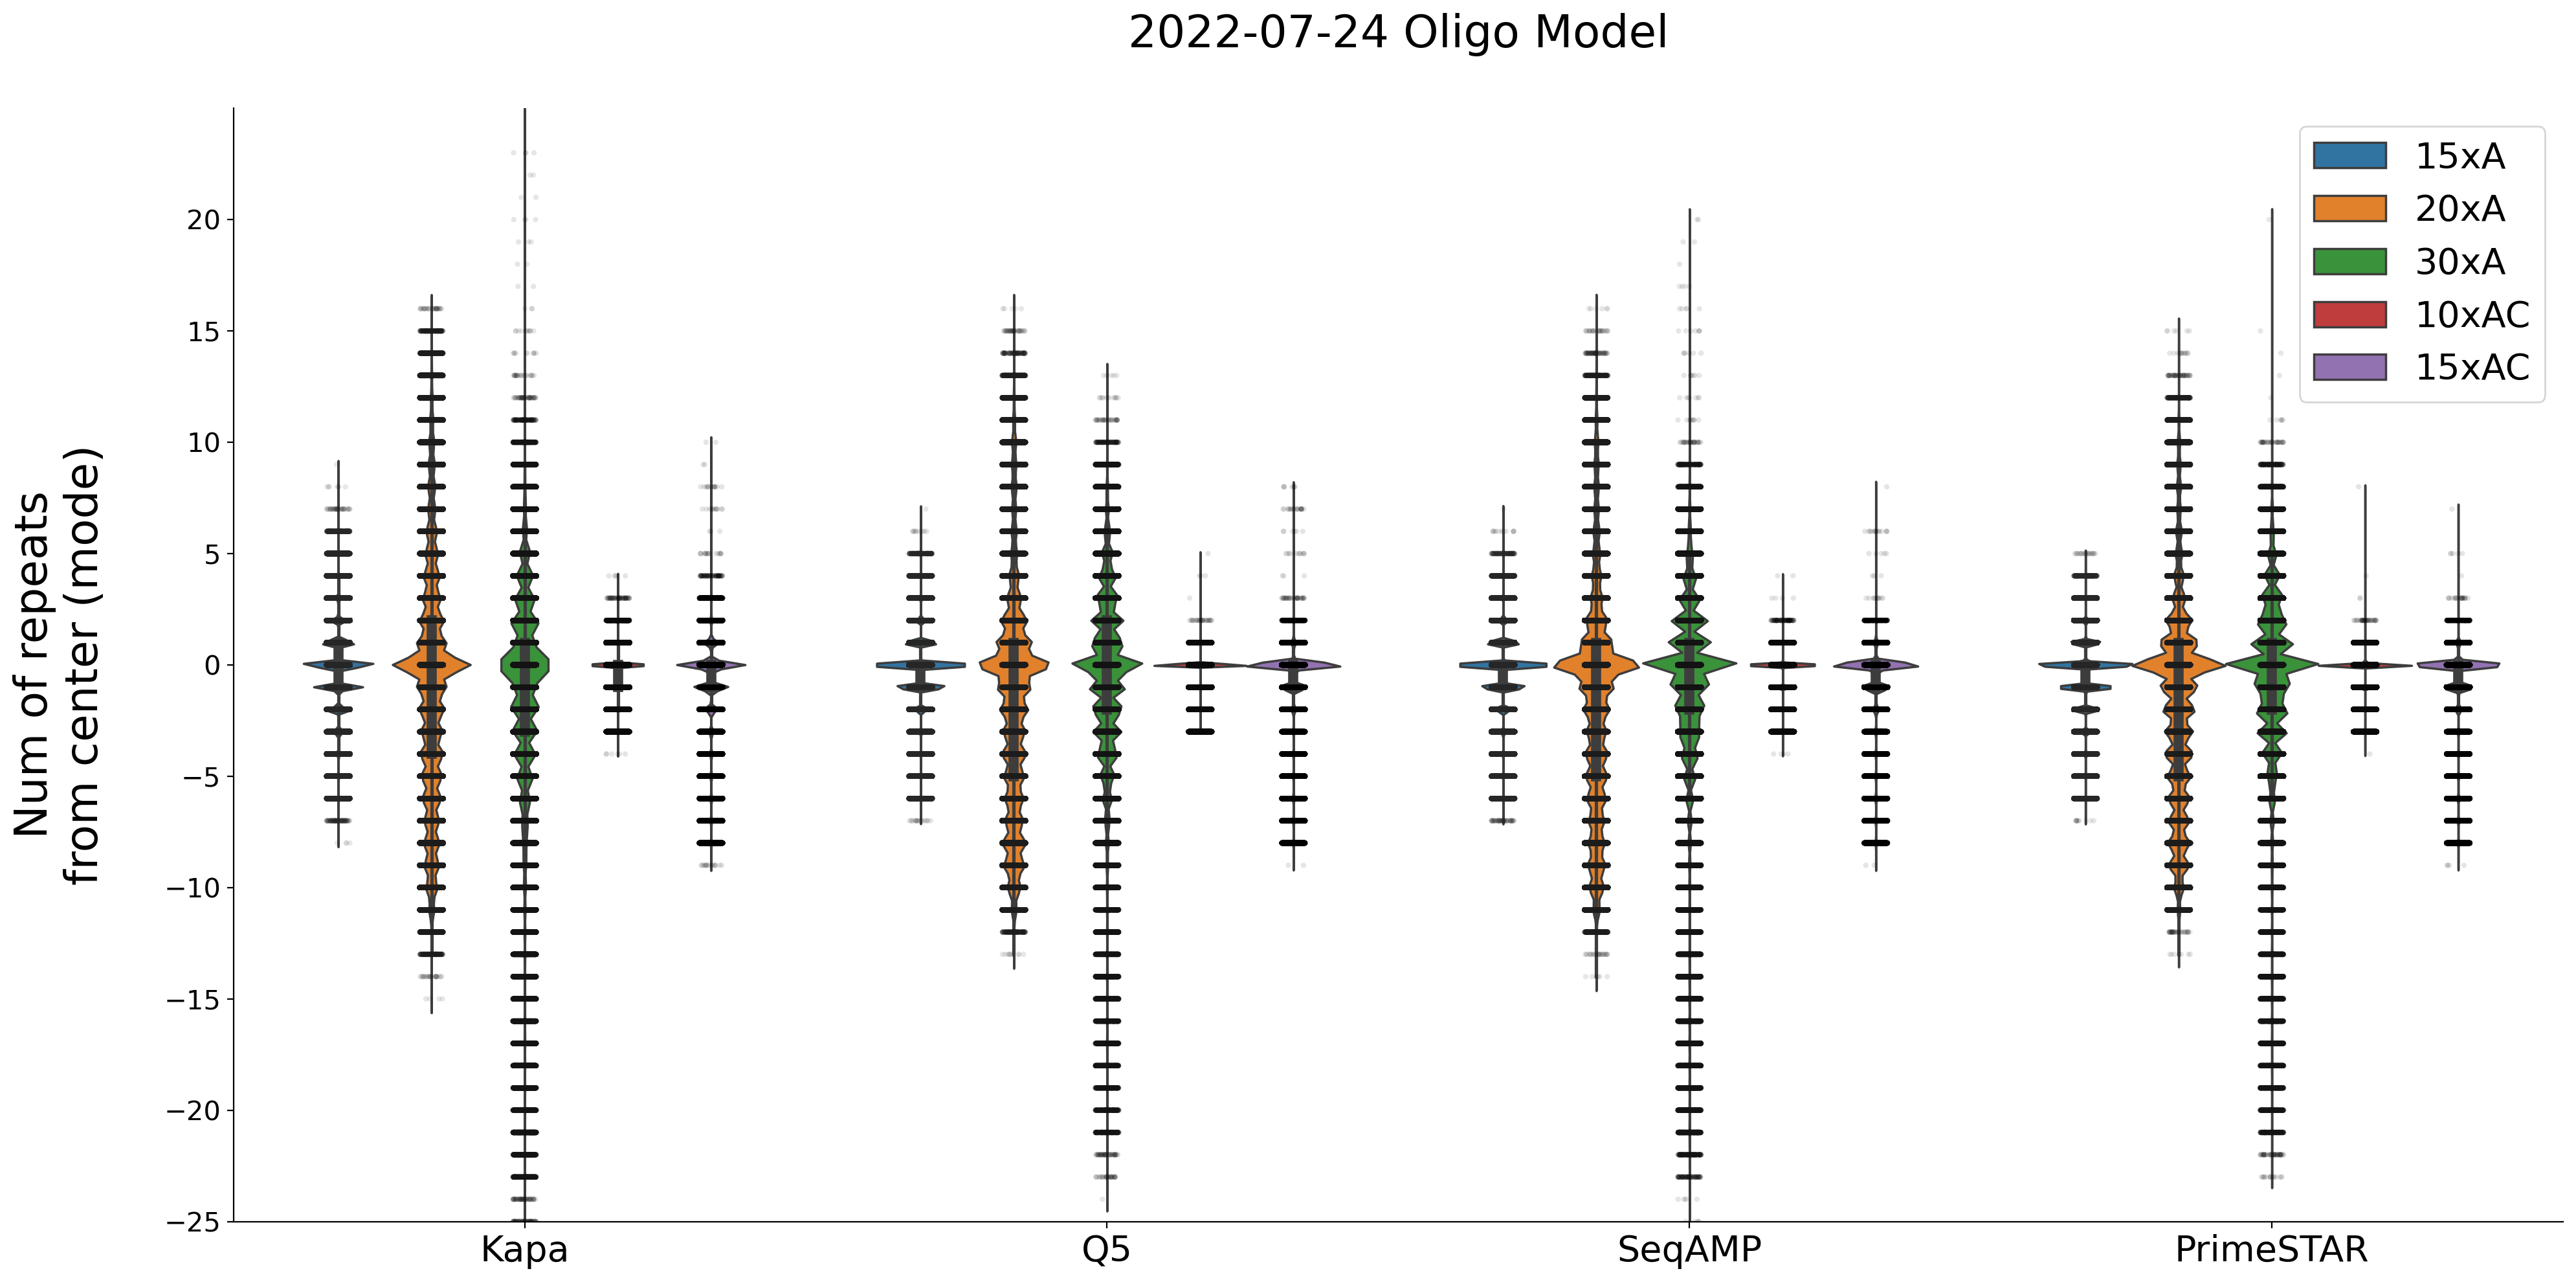

In [29]:
fig, ax = plt.subplots(figsize=(20,10), dpi=200)

sns.violinplot(x='exp', y='nrepeat_to_mode', data=comb_df, hue='lib_name', order=fname_ls,
               hue_order=['15xA', '20xA', '30xA', '10xAC', '15xAC'])
sns.stripplot(x='exp', y='nrepeat_to_mode', data=comb_df, hue='lib_name', color='black', size=3, dodge=True,
               order=fname_ls, hue_order=['15xA', '20xA', '30xA', '10xAC', '15xAC'], alpha=0.1)

ax.set_title('2022-07-24 Oligo Model\n', fontsize=25)
ax.set_xlabel("\n", fontsize=25)
ax.set_ylabel('Num of repeats\nfrom center (mode)\n', fontsize=25)
ax.tick_params(axis='both', labelsize=15)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(-25,25)
ax.set_yticks(np.arange(-25,25,5))
ax.tick_params(axis='x', which='major', labelsize=20)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:5], labels[:5], fontsize=20, loc='upper right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_331372/711164362.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='lib_name', y='nrepeat_to_mode', data=comb_df, hue='exp', color='black', size=3, dodge=True,


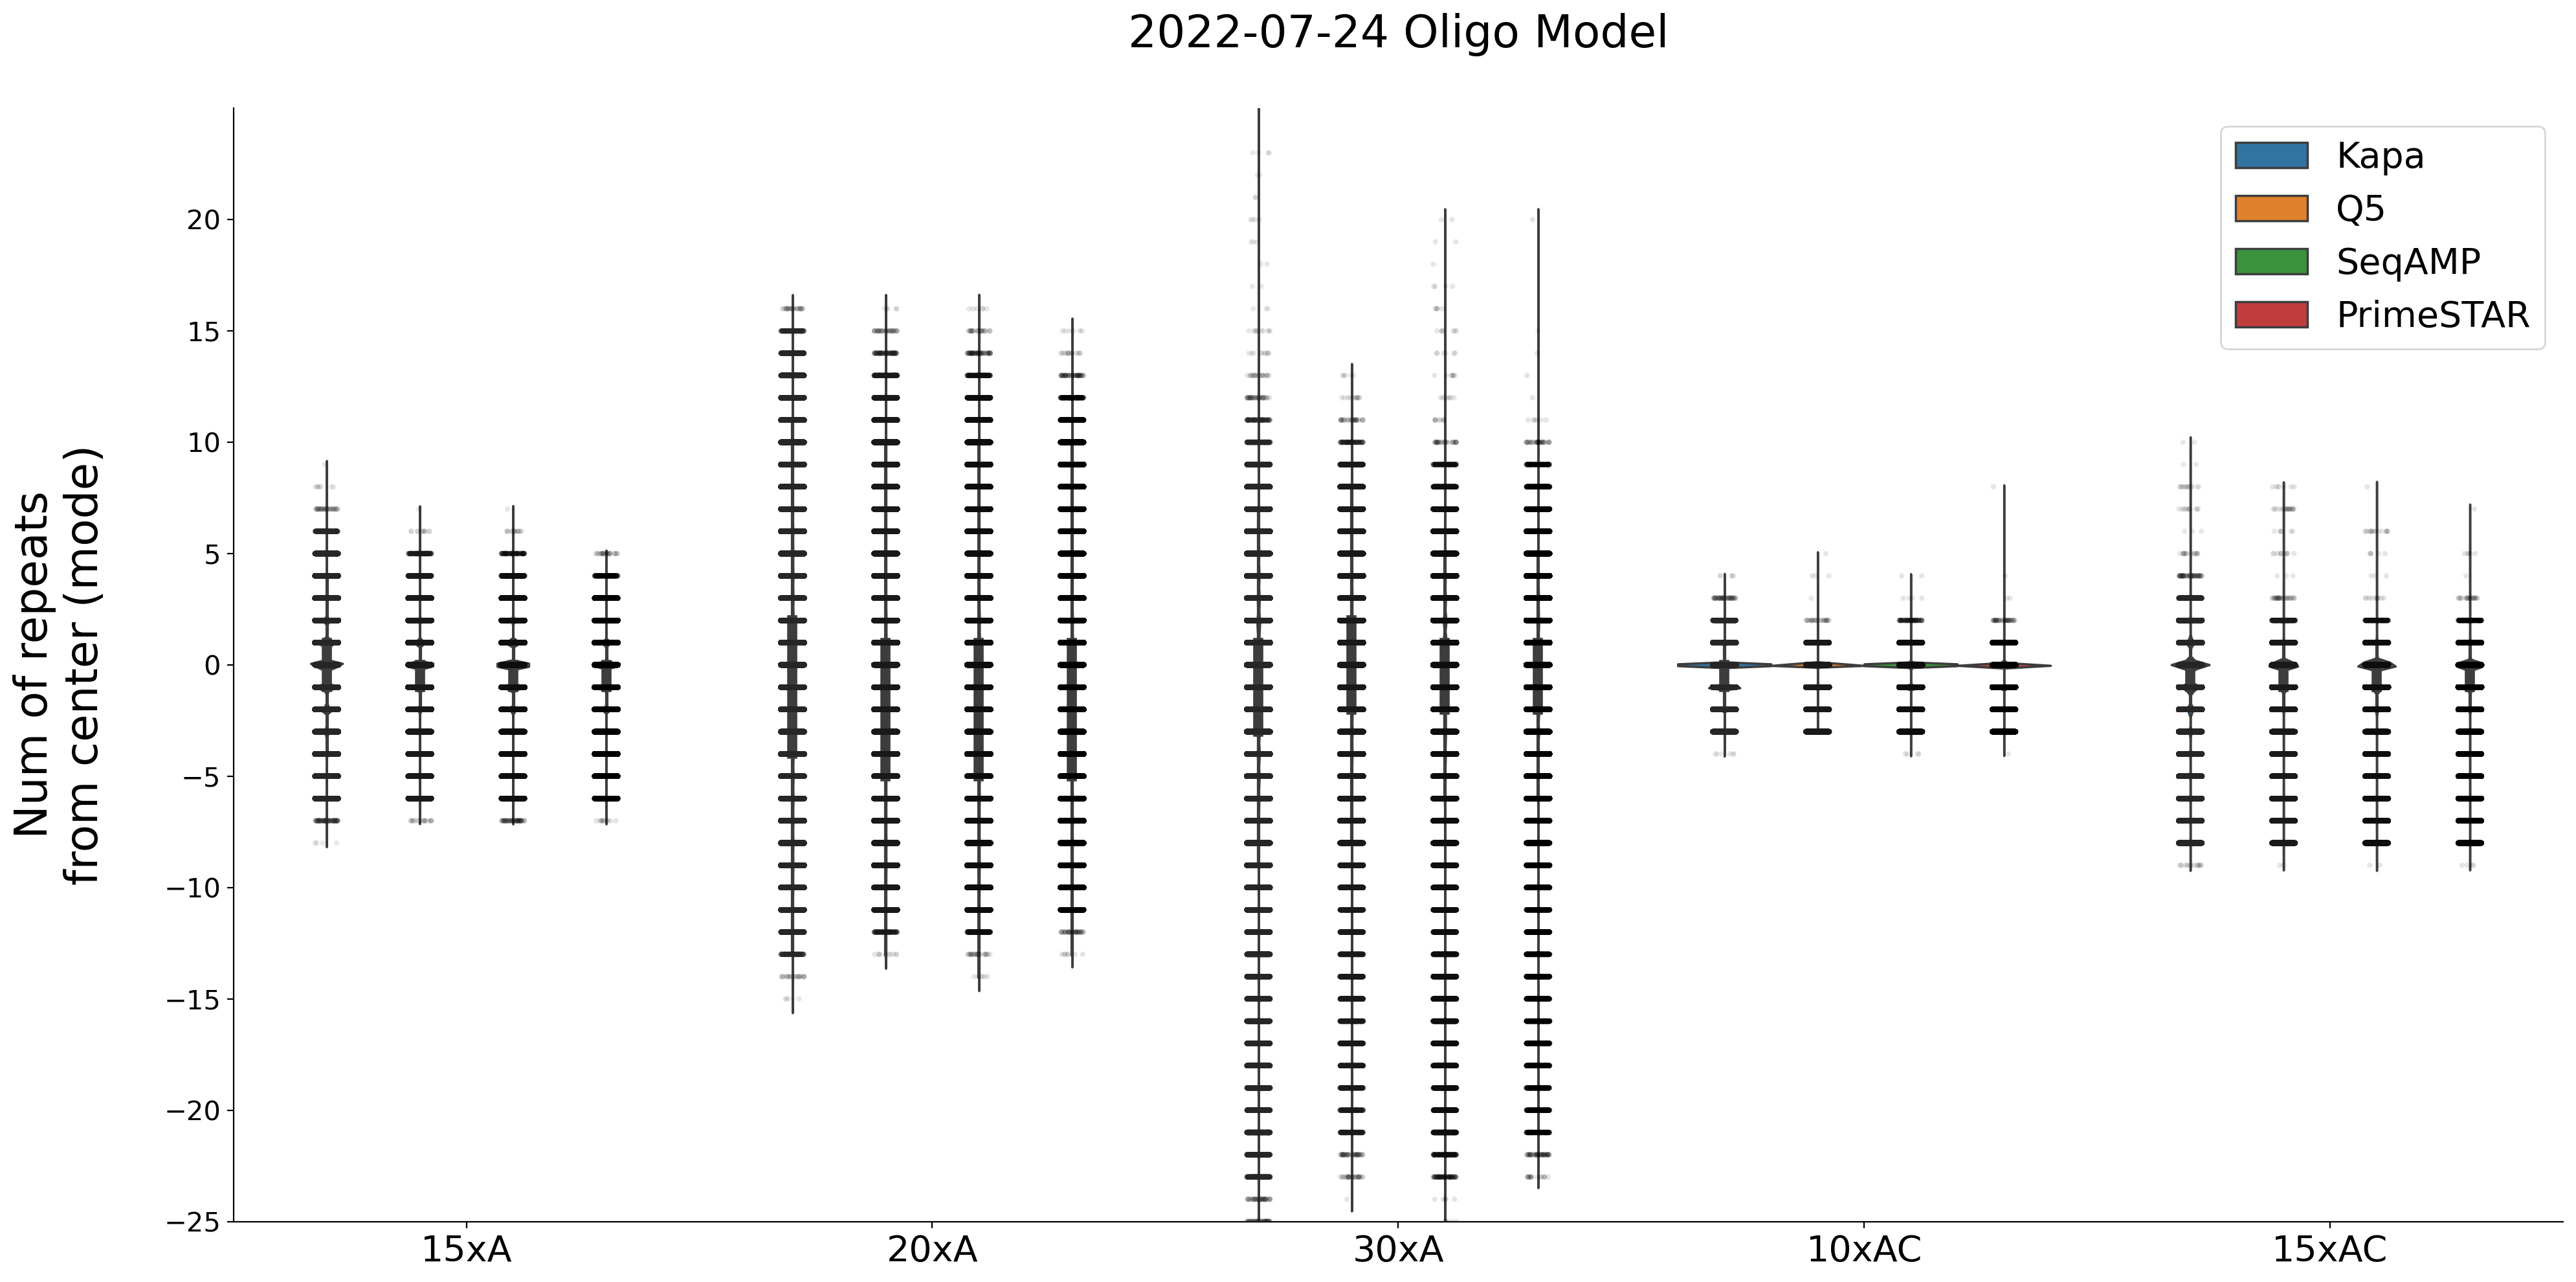

In [30]:
fig, ax = plt.subplots(figsize=(20,10), dpi=200)

sns.violinplot(x='lib_name', y='nrepeat_to_mode', data=comb_df, hue='exp', order=['15xA', '20xA', '30xA', '10xAC', '15xAC'],
               hue_order=fname_ls)
sns.stripplot(x='lib_name', y='nrepeat_to_mode', data=comb_df, hue='exp', color='black', size=3, dodge=True,
               order=['15xA', '20xA', '30xA', '10xAC', '15xAC'], hue_order=fname_ls, alpha=0.1)

ax.set_title('2022-07-24 Oligo Model\n', fontsize=25)
ax.set_xlabel("\n", fontsize=25)
ax.set_ylabel('Num of repeats\nfrom center (mode)\n', fontsize=25)
ax.tick_params(axis='both', labelsize=15)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(-25,25)
ax.set_yticks(np.arange(-25,25,5))
ax.tick_params(axis='x', which='major', labelsize=20)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:4], labels[:4], fontsize=20, loc='upper right')

plt.tight_layout()
plt.show()

# Check how much umi mode match oligo design
- this is a sanity check, ideally should be 80-90% based on olgio synthesis error, but looks like only ~50%, meaning other variables at play
- for example, sequencing error or early pcr error + amplification bias made them mode


In [31]:
# remove duplicate read, just analyze at umi level
comb_df_mode = comb_df[['umi', 'lib_name', 'mode_len_ms', 'ms_type', 'exp']]
comb_df_mode = comb_df_mode.drop_duplicates()
comb_df_mode = comb_df_mode.reset_index(drop=True)

In [32]:
# split by exp
gb = comb_df_mode.groupby('exp')
comb_df_mode_ls = [gb.get_group(x).reset_index(drop=True) for x in gb.groups]

In [33]:
group_ls = [df.exp[0] for df in comb_df_mode_ls]

In [34]:
# this check how much library oligo design match our oligo mode
for i, comb_df_mode in enumerate(comb_df_mode_ls):
    match_perc = sum([int(comb_df_mode.lib_name[i][:2])*comb_df_mode.ms_type[i] for i in range(comb_df_mode.shape[0])] == comb_df_mode.mode_len_ms)/comb_df_mode.shape[0]
    print(f'{group_ls[i]}: umi mode match oligo design: {round(match_perc*100, 2)}%')
    

Kapa: umi mode match oligo design: 52.53%
PrimeSTAR: umi mode match oligo design: 51.6%
Q5: umi mode match oligo design: 60.3%
SeqAMP: umi mode match oligo design: 63.74%


# Calculate Accuracy per umi

## Look at one umi for example

In [35]:
comb_df.query('ms_type == 1').umi.value_counts()[:10]

umi
GGCATTTGTGGTTTCACTTG    195
AAAGAGCGATATGACCCTAA    194
GTGTGCAGTTACTATGAACT    186
CTTTAACACAACACCGAAGT    180
GGTTTTTGATGCGTCATAAG    170
ATCATCTAAATTGGTATAAG    163
CAAATGCAGGCGGGTTCAGG    163
ACCGCTTTGCAGGTCTATTT    158
TCCGACATCACGTGGTAAGG    156
AACGGTTACCGCGTTTGGAT    155
Name: count, dtype: int64

In [36]:
umi_id = 'GGCATTTGTGGTTTCACTTG'

In [37]:
comb_df.ms[comb_df.umi == umi_id]

4029420     AAAAAAAAAAAAAAA
4047666     AAAAAAAAAAAAAAA
4071563     AAAAAAAAAAAAAAA
4101100    AAAAAAAAAAAAAAAA
4121272    AAAAAAAAAAAAAAAA
                 ...       
6801767     AAAAAAAAAAAAAAA
6808678      AAAAAAAAAAAAAA
6825206    AAAAAAAAAAAAAAAA
6828728      AAAAAAAAAAAAAA
6848134     AAAAAAAAAAAAAAA
Name: ms, Length: 195, dtype: object

In [38]:
counts = comb_df.len_ms[comb_df.umi == umi_id].value_counts()
counts

len_ms
15    101
14     43
16     29
13     18
17      2
12      2
Name: count, dtype: int64

In [39]:
sum(counts)

195

In [40]:
# percent of most frequent
counts.iloc[0]/sum(counts)

0.517948717948718

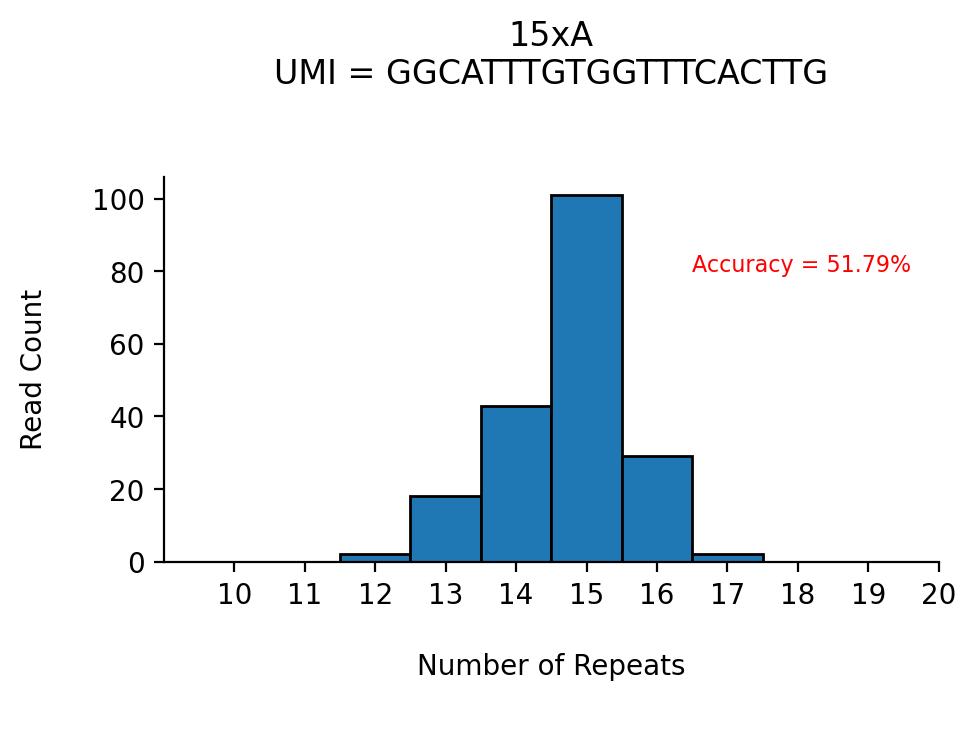

In [41]:
n_repeat = 15
motif = 'A'

fig, ax = plt.subplots(figsize=(5,2.5), dpi=200)
plt.hist(comb_df.len_ms[comb_df.umi == umi_id], np.arange(n_repeat-5,n_repeat+6), edgecolor='black', color='tab:blue')

ax.set_title(f'{n_repeat}x{motif}\nUMI = {umi_id}\n\n')#, fontsize=10)
ax.set_ylabel('Read Count\n')
ax.set_xlabel('\nNumber of Repeats\n')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# work around to set n_repeat to center of tick
ax.set_xticks(np.arange(n_repeat-5+0.5,n_repeat+6+0.5))
ax.set_xticklabels(np.arange(n_repeat-5,n_repeat+6))
#ax.set_yticks(np.arange(0,11,2))

# add text percent of most frequent
ax.text(n_repeat+2, 80, f'Accuracy = {round(counts.iloc[0]/sum(counts)*100, 2)}%', size=8, c='red')

plt.show()

In [42]:
comb_df.query('ms_type == 2').umi.value_counts()[:10]

umi
TCGTTAGGAAGACAGGGAAT    191
ATTACCTGTAATGGTTAGCG    188
CGACTTAAGAAACCTTTTGT    179
GAGTTGGTTCTTTGTCAGTT    178
TCTGCAAGATGTAAATTGTT    178
TAAGGCACCGCTCCGCGATA    165
CACTGTTGCGTTGCGCATTA    165
TTTGTTTATTTGTGTGGAGT    158
TCTTTTTGCTAACATTCTCC    155
GTATGGTGGTATGAGGTATA    154
Name: count, dtype: int64

In [43]:
umi_id = 'ATTACCTGTAATGGTTAGCG'

In [44]:
comb_df.ms[comb_df.umi == umi_id]

4032838    ACACACACACACACACACACACACACACAC
4042943    ACACACACACACACACACACACACACACAC
4052901        ACACACACACACACACACACACACAC
4065243      ACACACACACACACACACACACACACAC
4081943    ACACACACACACACACACACACACACACAC
                        ...              
6751129        ACACACACACACACACACACACACAC
6776477    ACACACACACACACACACACACACACACAC
6810357      ACACACACACACACACACACACACACAC
6846552    ACACACACACACACACACACACACACACAC
6849840    ACACACACACACACACACACACACACACAC
Name: ms, Length: 188, dtype: object

In [45]:
counts = comb_df.len_ms[comb_df.umi == umi_id].value_counts()
counts

len_ms
30    114
28     43
26      9
32      7
20      6
18      4
14      2
22      2
16      1
Name: count, dtype: int64

In [46]:
counts.iloc[0]/sum(counts)

0.6063829787234043

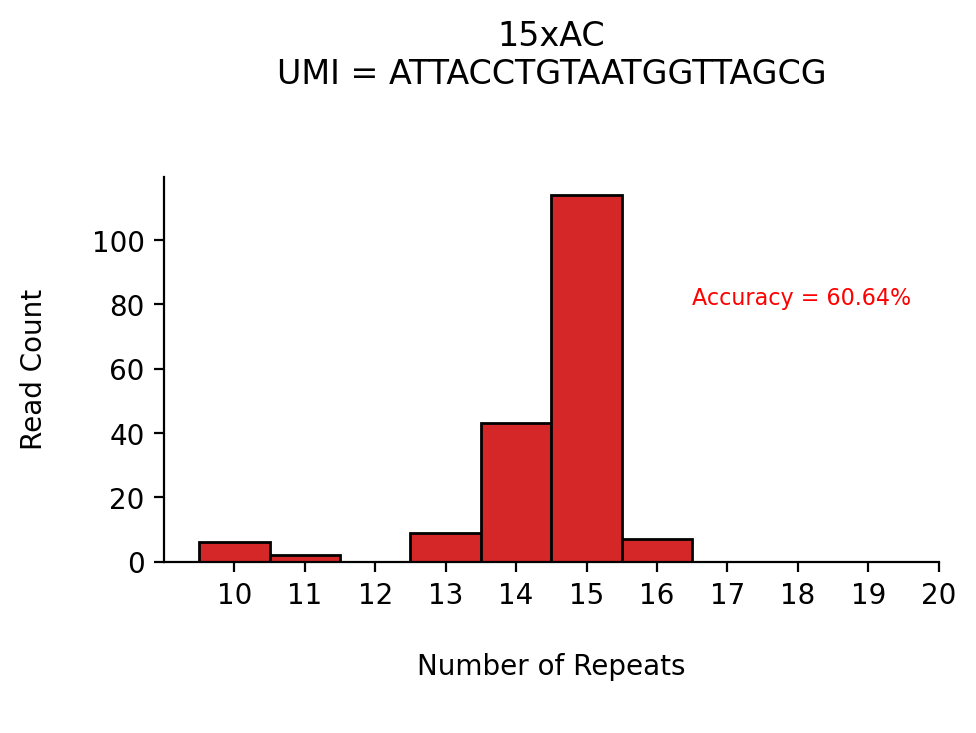

In [47]:
n_repeat = 15
motif = 'AC'

fig, ax = plt.subplots(figsize=(5,2.5), dpi=200)
plt.hist(comb_df.len_ms[comb_df.umi == umi_id]/len(motif), np.arange(n_repeat-5,n_repeat+6), edgecolor='black', color='tab:red')

ax.set_title(f'{n_repeat}x{motif}\nUMI = {umi_id}\n\n')#, fontsize=10)
ax.set_ylabel('Read Count\n')
ax.set_xlabel('\nNumber of Repeats\n')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# work around to set n_repeat to center of tick
ax.set_xticks(np.arange(n_repeat-5+0.5,n_repeat+6+0.5))
ax.set_xticklabels(np.arange(n_repeat-5,n_repeat+6))

# add text percent of most frequent
ax.text(n_repeat+2, 80, f'Accuracy = {round(counts.iloc[0]/sum(counts)*100, 2)}%', size=8, c='red')

plt.show()

## Look at all UMI accuracy

In [48]:
# per umi accuracy, extract n_read with 0 repeat to mode (accurate) / sum  
umi_acc = comb_df.groupby('umi_exp_libname')['nrepeat_to_mode'].agg(lambda x: x.value_counts()[0]/sum(x.value_counts())*100)  
umi_acc_df = pd.DataFrame({'umi_exp_libname':umi_acc.index, 'umi_accuracy':umi_acc.values})

In [49]:
umi_to_meta = comb_df[['umi_exp_libname', 'umi', 'exp', 'lib_name']].drop_duplicates()
umi_acc_df = pd.merge(umi_acc_df, umi_to_meta, on='umi_exp_libname')
umi_acc_df

,umi_exp_libname,umi_accuracy,umi,exp,lib_name
0,AAAAAAAGTGGCATATTGGA_PrimeSTAR_10xAC,87.500000,AAAAAAAGTGGCATATTGGA,PrimeSTAR,10xAC
1,AAAAAAAGTTGTTTTAAATC_Kapa_10xAC,80.000000,AAAAAAAGTTGTTTTAAATC,Kapa,10xAC
2,AAAAAAATGATTTTACTGCG_Kapa_10xAC,78.571429,AAAAAAATGATTTTACTGCG,Kapa,10xAC
3,AAAAAACACATATGTATATT_SeqAMP_30xA,30.434783,AAAAAACACATATGTATATT,SeqAMP,30xA
4,AAAAAACACCAAGATGCCAT_PrimeSTAR_15xA,48.275862,AAAAAACACCAAGATGCCAT,PrimeSTAR,15xA
...,...,...,...,...,...
384557,TTTTTTTTTTACATATATTA_Q5_15xA,64.705882,TTTTTTTTTTACATATATTA,Q5,15xA
384558,TTTTTTTTTTACGTCATACT_Kapa_15xA,28.571429,TTTTTTTTTTACGTCATACT,Kapa,15xA
384559,TTTTTTTTTTGCATCTCCTG_SeqAMP_15xA,56.000000,TTTTTTTTTTGCATCTCCTG,SeqAMP,15xA
384560,TTTTTTTTTTGTTTGATTAC_Kapa_15xA,46.153846,TTTTTTTTTTGTTTGATTAC,Kapa,15xA


## Stats

In [50]:
umi_acc_df.groupby(['exp', 'lib_name']).describe()

umi_accuracy                                              \
                          count       mean        std        min        25%   
exp       lib_name                                                            
Kapa      10xAC         13644.0  68.891437  10.201826  25.000000  62.500000   
          15xA          40719.0  37.206475   7.464469  16.666667  31.914894   
          15xAC         12168.0  47.168386   9.327711  22.222222  40.625000   
          20xA          34471.0  19.338049   5.014418   8.571429  15.789474   
          30xA          30514.0  21.982938   5.703218   8.333333  17.948718   
PrimeSTAR 10xAC         10105.0  87.073496   7.795792  41.666667  83.333333   
          15xA          26826.0  44.352271   8.343668  20.000000  38.461538   
          15xAC          8774.0  66.810410  10.022986  26.315789  60.869565   
          20xA          23436.0  21.401863   5.676169   9.375000  17.391304   
          30xA          19417.0  25.015691   6.289192   9.090909  20.588235   
Q5        10xAC          6531.0  89.572753   6.524638  45.333333  86.666667   
          15xA          16637.0  49.941308   8.603362  23.404255  44.117647   
          15xAC          5608.0  68.487349   9.009532  34.285714  63.636364   
          20xA          14935.0  18.897289   5.165910   8.333333  15.492958   
          30xA          12890.0  21.311746   5.493039   9.677419  17.500000   
SeqAMP    10xAC         11535.0  82.825699   9.618487  40.000000  77.777778   
          15xA          32715.0  48.894618  10.006683  20.000000  41.666667   
          15xAC         10277.0  65.372248  11.195099  26.666667  57.894737   
          20xA          27688.0  22.460308   6.140315   9.090909  18.181818   
          30xA          25672.0  25.719705   6.732683   9.090909  21.052632   

                                                      
                          50%        75%         max  
exp       lib_name                                    
Kapa      10xAC     69.565217  75.862069  100.000000  
          15xA      36.363636  41.666667  100.000000  
          15xAC     46.428571  52.727273  100.000000  
          20xA      18.518519  21.739130  100.000000  
          30xA      21.052632  25.000000   97.368421  
PrimeSTAR 10xAC     88.095238  92.156863  100.000000  
          15xA      43.478261  50.000000  100.000000  
          15xAC     67.500000  73.333333  100.000000  
          20xA      20.000000  24.324324  100.000000  
          30xA      24.000000  28.571429  100.000000  
Q5        10xAC     90.322581  93.478261  100.000000  
          15xA      50.000000  55.000000  100.000000  
          15xAC     69.230769  74.074074  100.000000  
          20xA      17.857143  21.052632  100.000000  
          30xA      20.000000  23.809524   98.360656  
SeqAMP    10xAC     84.000000  89.473684  100.000000  
          15xA      48.387097  55.555556  100.000000  
          15xAC     65.714286  72.972973  100.000000  
          20xA      21.428571  25.714286  100.000000  
          30xA      25.000000  29.411765   93.333333

In [51]:
umi_acc_df.groupby(['lib_name', 'exp']).describe()#.reindex([('15xA','30cycles'), ('15xA','35cycles'), ('15xA','40cycles'),
#                                                                  ('20xA','30cycles'), ('20xA','35cycles'), ('20xA','40cycles'),
#                                                                  ('30xA','30cycles'), ('30xA','35cycles'), ('30xA','40cycles'),
#                                                                  ('10xAC','30cycles'), ('10xAC','35cycles'), ('10xAC','40cycles'),
#                                                                  ('15xAC','30cycles'), ('15xAC','35cycles'), ('15xAC','40cycles')])


umi_accuracy                                              \
                          count       mean        std        min        25%   
lib_name exp                                                                  
10xAC    Kapa           13644.0  68.891437  10.201826  25.000000  62.500000   
         PrimeSTAR      10105.0  87.073496   7.795792  41.666667  83.333333   
         Q5              6531.0  89.572753   6.524638  45.333333  86.666667   
         SeqAMP         11535.0  82.825699   9.618487  40.000000  77.777778   
15xA     Kapa           40719.0  37.206475   7.464469  16.666667  31.914894   
         PrimeSTAR      26826.0  44.352271   8.343668  20.000000  38.461538   
         Q5             16637.0  49.941308   8.603362  23.404255  44.117647   
         SeqAMP         32715.0  48.894618  10.006683  20.000000  41.666667   
15xAC    Kapa           12168.0  47.168386   9.327711  22.222222  40.625000   
         PrimeSTAR       8774.0  66.810410  10.022986  26.315789  60.869565   
         Q5              5608.0  68.487349   9.009532  34.285714  63.636364   
         SeqAMP         10277.0  65.372248  11.195099  26.666667  57.894737   
20xA     Kapa           34471.0  19.338049   5.014418   8.571429  15.789474   
         PrimeSTAR      23436.0  21.401863   5.676169   9.375000  17.391304   
         Q5             14935.0  18.897289   5.165910   8.333333  15.492958   
         SeqAMP         27688.0  22.460308   6.140315   9.090909  18.181818   
30xA     Kapa           30514.0  21.982938   5.703218   8.333333  17.948718   
         PrimeSTAR      19417.0  25.015691   6.289192   9.090909  20.588235   
         Q5             12890.0  21.311746   5.493039   9.677419  17.500000   
         SeqAMP         25672.0  25.719705   6.732683   9.090909  21.052632   

                                                      
                          50%        75%         max  
lib_name exp                                          
10xAC    Kapa       69.565217  75.862069  100.000000  
         PrimeSTAR  88.095238  92.156863  100.000000  
         Q5         90.322581  93.478261  100.000000  
         SeqAMP     84.000000  89.473684  100.000000  
15xA     Kapa       36.363636  41.666667  100.000000  
         PrimeSTAR  43.478261  50.000000  100.000000  
         Q5         50.000000  55.000000  100.000000  
         SeqAMP     48.387097  55.555556  100.000000  
15xAC    Kapa       46.428571  52.727273  100.000000  
         PrimeSTAR  67.500000  73.333333  100.000000  
         Q5         69.230769  74.074074  100.000000  
         SeqAMP     65.714286  72.972973  100.000000  
20xA     Kapa       18.518519  21.739130  100.000000  
         PrimeSTAR  20.000000  24.324324  100.000000  
         Q5         17.857143  21.052632  100.000000  
         SeqAMP     21.428571  25.714286  100.000000  
30xA     Kapa       21.052632  25.000000   97.368421  
         PrimeSTAR  24.000000  28.571429  100.000000  
         Q5         20.000000  23.809524   98.360656  
         SeqAMP     25.000000  29.411765   93.333333

## Plot

/tmp/ipykernel_331372/2494098952.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='exp', y='umi_accuracy', data=umi_acc_df, hue='lib_name', color='black', size=3, dodge=True,


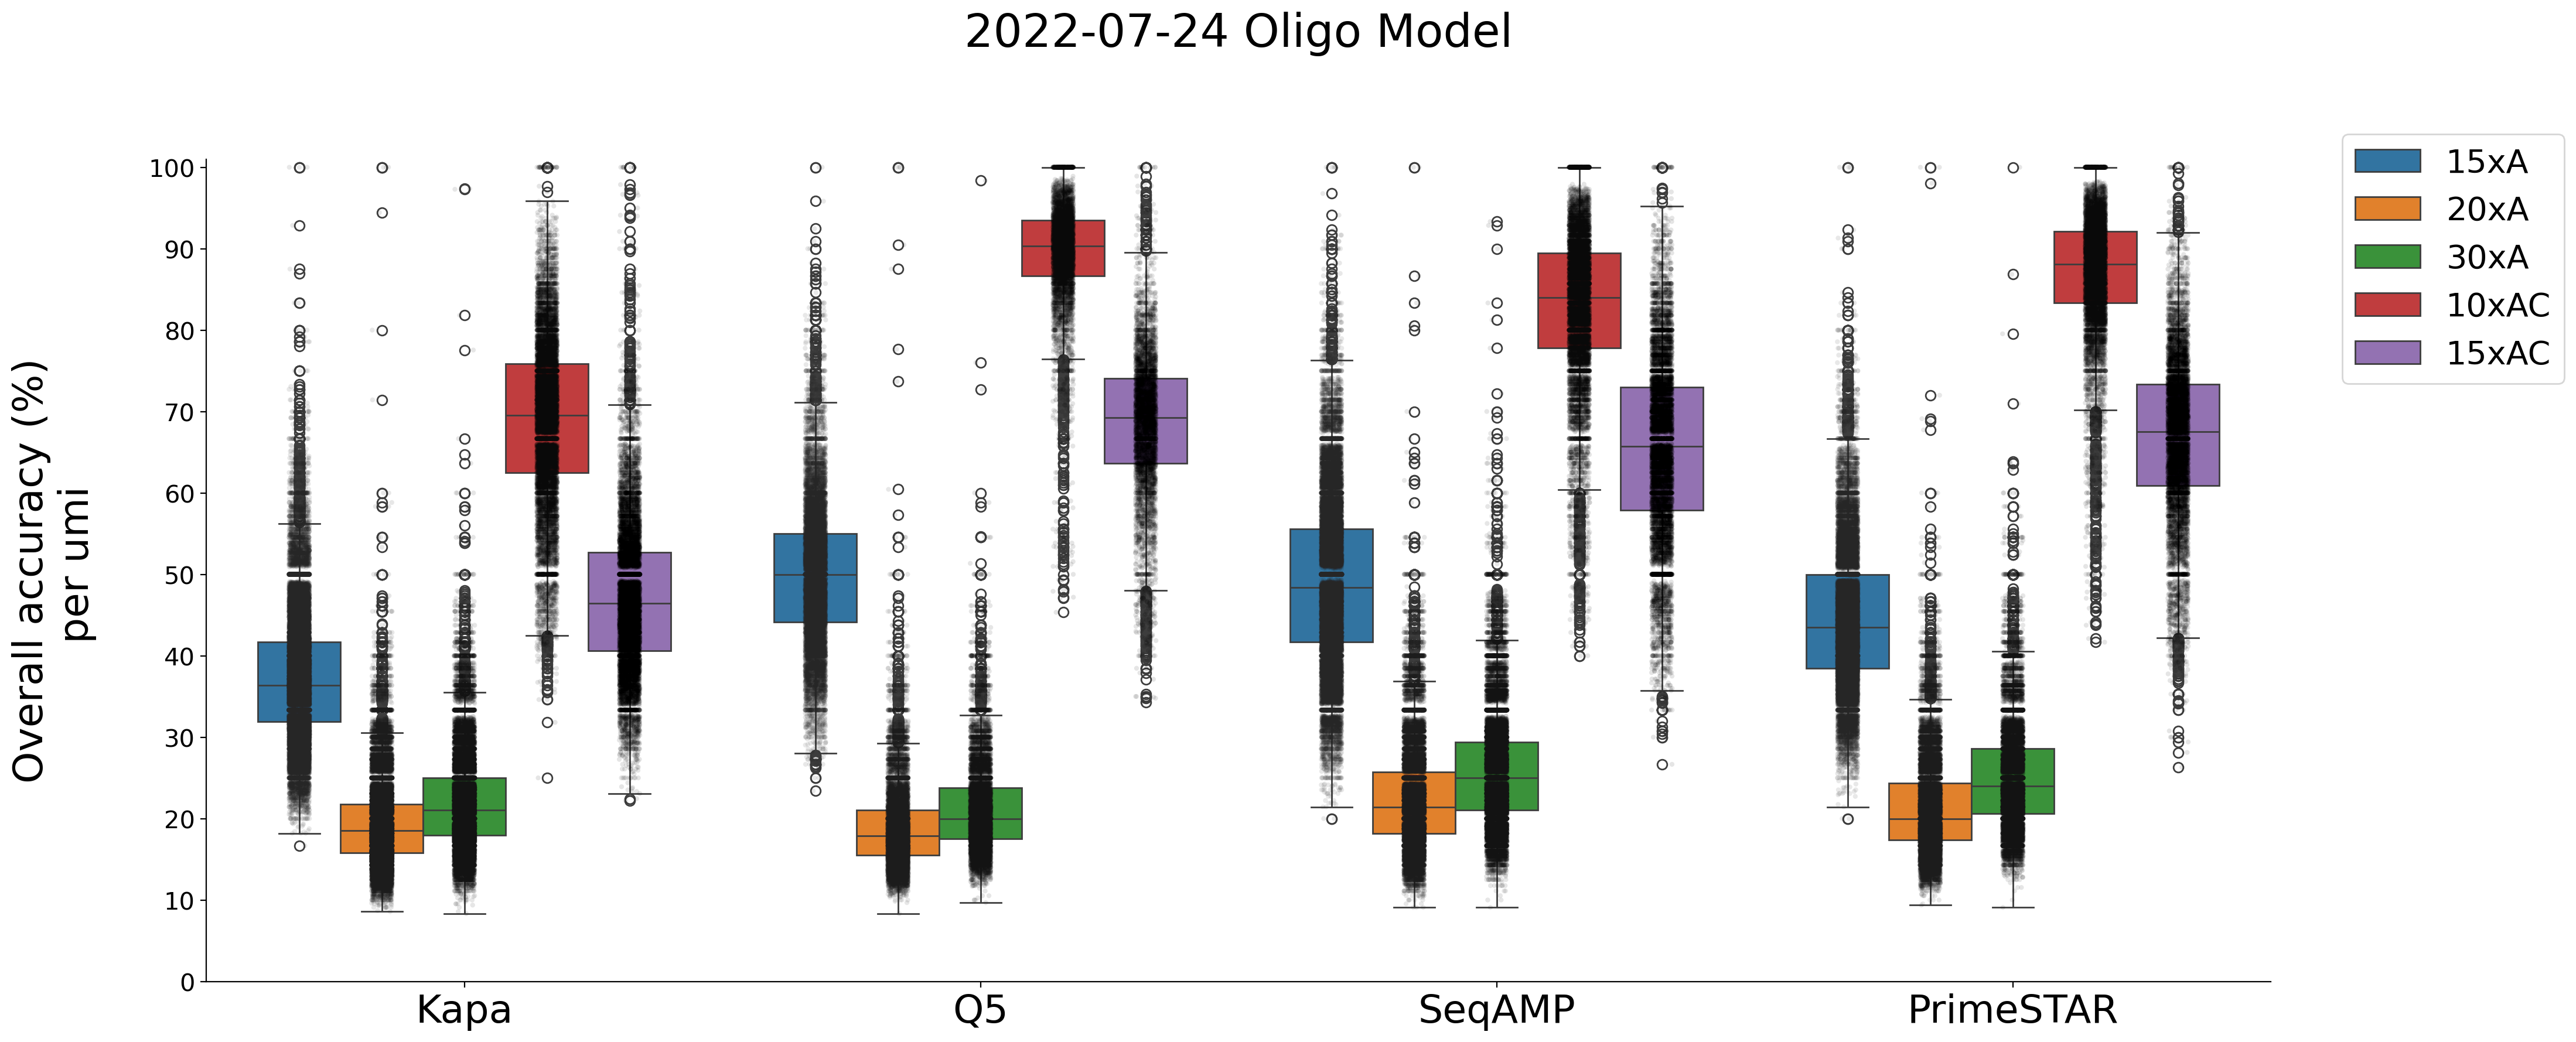

In [52]:
fig, ax = plt.subplots(figsize=(22,9), dpi=200)

sns.boxplot(x='exp', y='umi_accuracy', data=umi_acc_df, hue='lib_name', order=fname_ls,
               hue_order=['15xA', '20xA', '30xA', '10xAC', '15xAC'])
sns.stripplot(x='exp', y='umi_accuracy', data=umi_acc_df, hue='lib_name', color='black', size=3, dodge=True,
               order=fname_ls, hue_order=['15xA', '20xA', '30xA', '10xAC', '15xAC'], alpha=0.1)

ax.set_title('2022-07-24 Oligo Model\n\n', fontsize=28)
ax.set_xlabel("\n", fontsize=25)
ax.set_ylabel('Overall accuracy (%)\n per umi\n', fontsize=25)
ax.tick_params(axis='both', labelsize=15)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(0,101)
ax.set_yticks(np.arange(0,101,10))
ax.tick_params(axis='x', which='major', labelsize=24)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:5], labels[:5], fontsize=20, loc='upper right', bbox_to_anchor=(1.15, 1.05))

plt.tight_layout()
plt.show()

/tmp/ipykernel_331372/1617161646.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='lib_name', y='umi_accuracy', data=umi_acc_df, hue='exp', color='black', size=3, dodge=True,


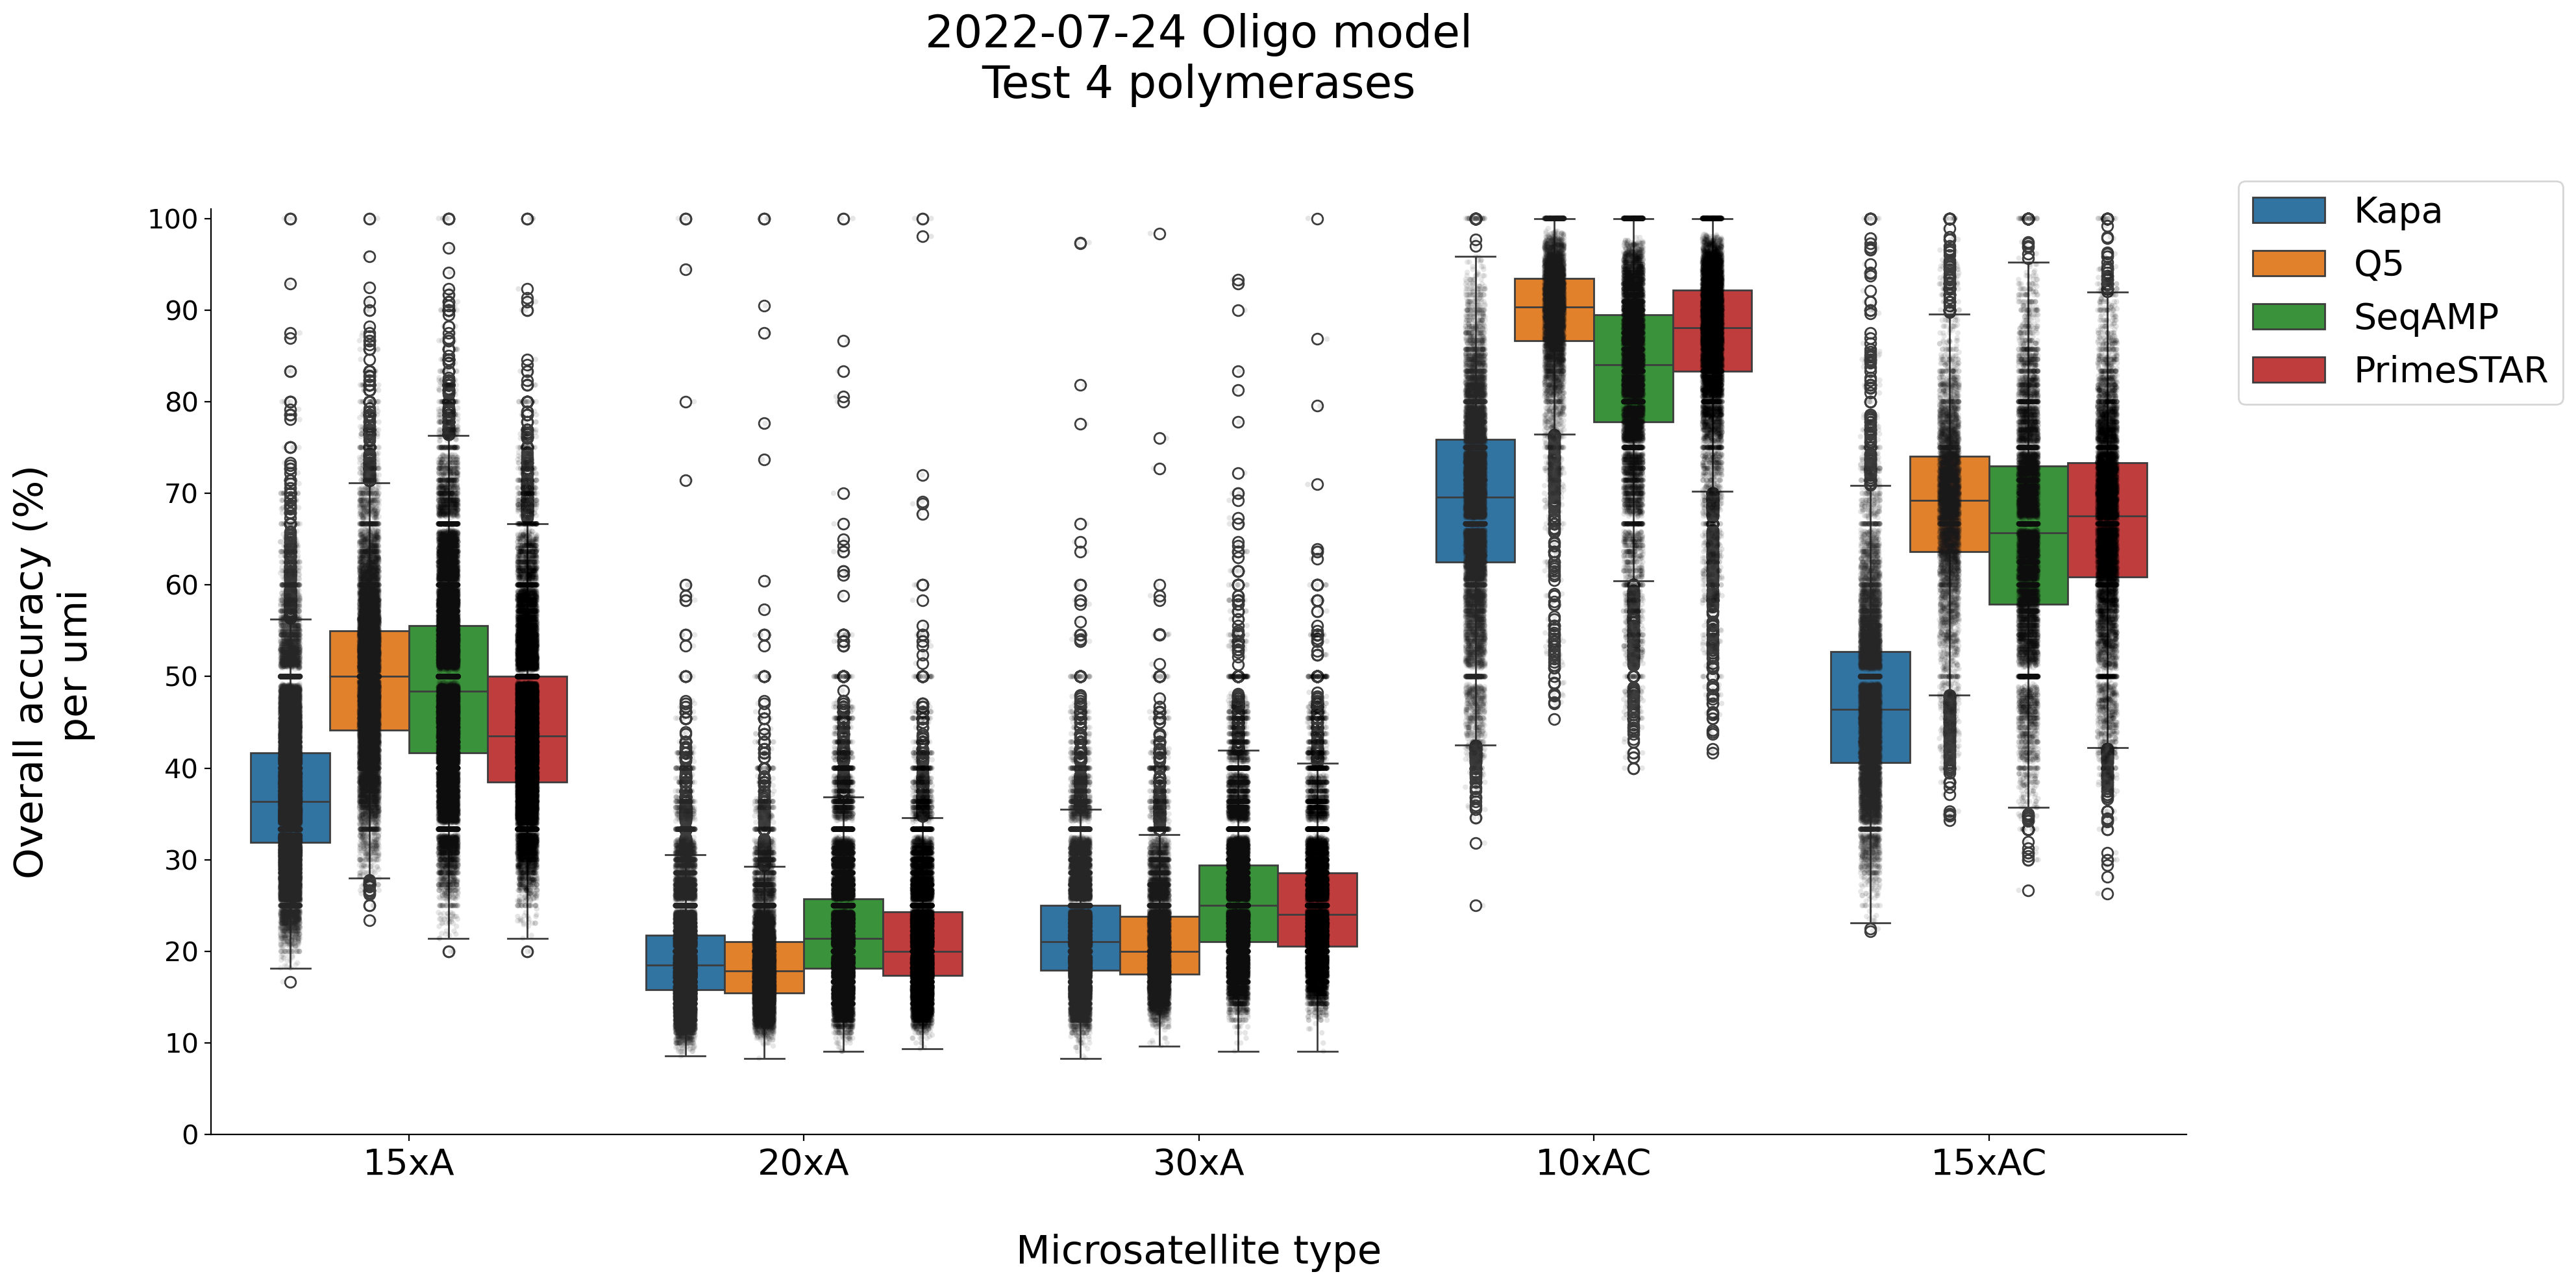

In [53]:
#my_palette = [sns.color_palette()[i] for i in [5,6,8,9]] #if you want set different color

fig, ax = plt.subplots(figsize=(20,10), dpi=200)

sns.boxplot(x='lib_name', y='umi_accuracy', data=umi_acc_df, hue='exp', order=['15xA', '20xA', '30xA', '10xAC', '15xAC'],
               hue_order=fname_ls)
sns.stripplot(x='lib_name', y='umi_accuracy', data=umi_acc_df, hue='exp', color='black', size=3, dodge=True,
               order=['15xA', '20xA', '30xA', '10xAC', '15xAC'], hue_order=fname_ls, alpha=0.1)

ax.set_title('2022-07-24 Oligo model\nTest 4 polymerases\n\n', fontsize=25)
ax.set_xlabel("\nMicrosatellite type", fontsize=22)
ax.set_ylabel('Overall accuracy (%)\n per umi\n', fontsize=22)
ax.tick_params(axis='both', labelsize=15)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(0,101)
ax.set_yticks(np.arange(0,101,10))
ax.tick_params(axis='x', which='major', labelsize=20)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:4], labels[:4], fontsize=20, loc='upper right', bbox_to_anchor=(1.2, 1.05))

plt.tight_layout()
plt.show()

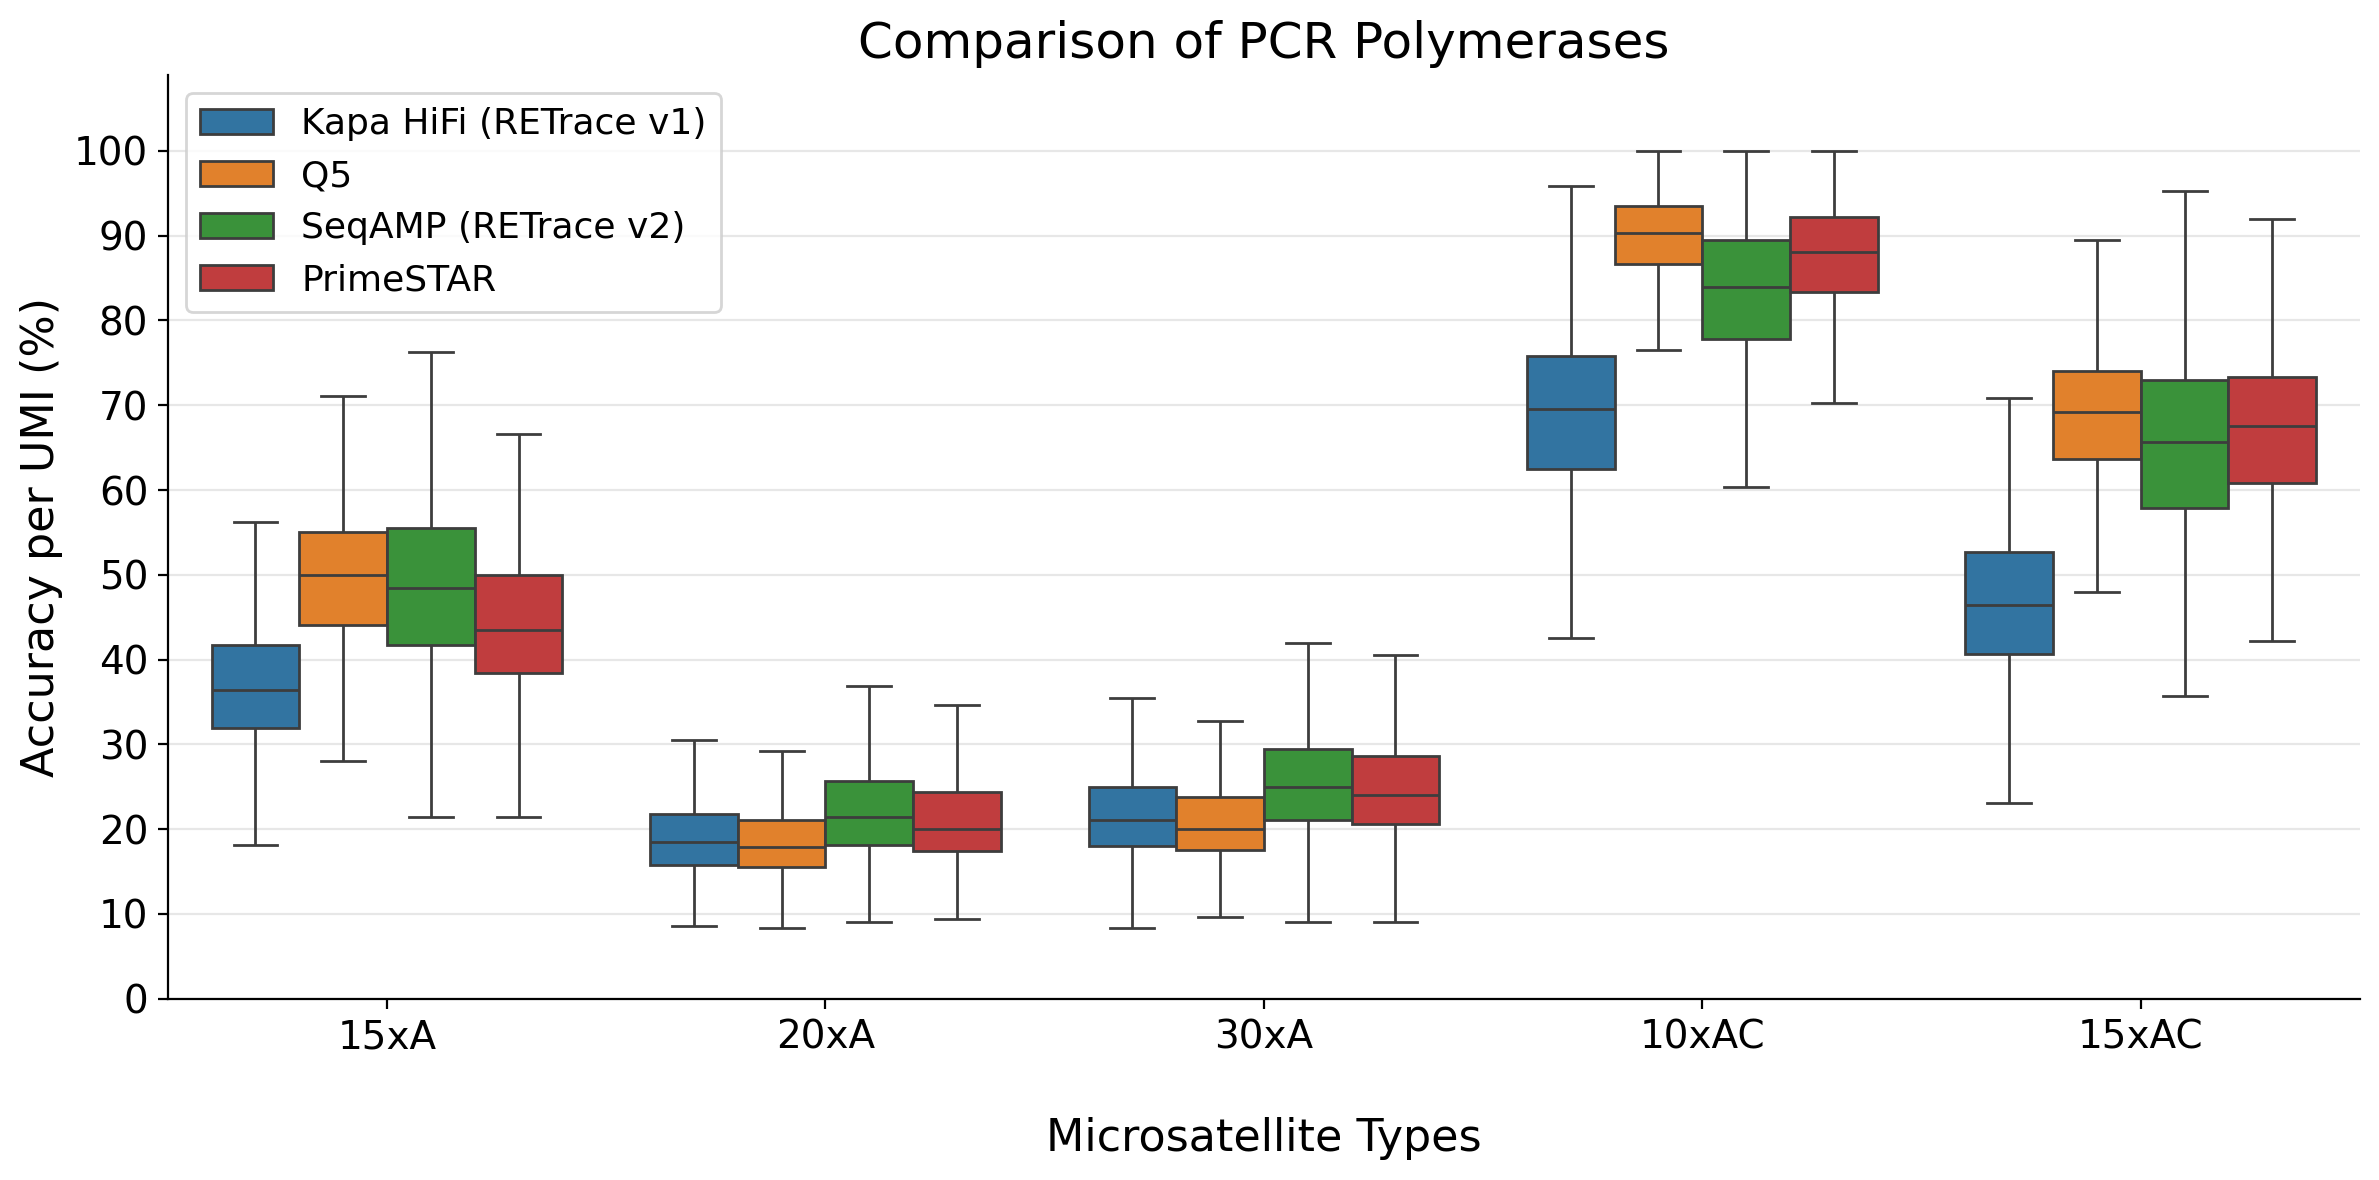

In [ ]:
fig, ax = plt.subplots(figsize=(12,6), dpi=200)

sns.boxplot(x='lib_name', y='umi_accuracy', data=umi_acc_df, hue='exp', order=['15xA', '20xA', '30xA', '10xAC', '15xAC'],
               hue_order=fname_ls, showfliers=False)

ax.set_title('Comparison of PCR Polymerases', fontsize=18)
ax.set_xlabel("\nMicrosatellite Types", fontsize=16)
ax.set_ylabel('Accuracy per UMI (%)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)

ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylim(0,109)
ax.set_yticks(np.arange(0,101,10))

handles, labels = ax.get_legend_handles_labels()
labels[0] = "Kapa HiFi (RETrace v1)"  # change Kapa to Kapa Hifi to be more clear
labels[2] = "SeqAMP (RETrace v2)"  # change SeqAMP to SeqAMP (RETrace v2) to be more clear
ax.legend(handles[:4], labels[:4], fontsize=13, loc='upper left')

plt.tight_layout()
plt.savefig('Test_Polymerase.pdf')
plt.show()

# Statistic Test
- Mann-Whitney U tests: Compare each polymerase to Kapa HiFi (control)


In [55]:
# Get all microsatellite types
ms_types = ['15xA', '20xA', '30xA', '10xAC', '15xAC']
polymerases_to_test = ['Q5', 'SeqAMP', 'PrimeSTAR']

# Store all results
all_results = []

print("Mann-Whitney U Tests - Comparing to Kapa HiFi (control)")
print("Analysis by Microsatellite Type")
print("=" * 80)

for ms_type in ms_types:
    print(f"\n🧬 MICROSATELLITE TYPE: {ms_type}")
    print("-" * 50)
    
    # Filter data for this microsatellite type
    ms_data = umi_acc_df[umi_acc_df['lib_name'] == ms_type]
    
    # Get Kapa HiFi data for this microsatellite type
    kapa_data = ms_data[ms_data['exp'] == 'Kapa']['umi_accuracy']
    
    if len(kapa_data) == 0:
        print(f"  ⚠️  No Kapa data found for {ms_type}")
        continue
    
    for poly in polymerases_to_test:
        poly_data = ms_data[ms_data['exp'] == poly]['umi_accuracy']
        
        if len(poly_data) == 0:
            print(f"  ⚠️  No {poly} data found for {ms_type}")
            continue
        
        # Mann-Whitney U test (two-sided)
        statistic, p_value = mannwhitneyu(kapa_data, poly_data, alternative='two-sided')
        
        # Calculate effect size (rank-biserial correlation)
        n1, n2 = len(kapa_data), len(poly_data)
        effect_size = 1 - (2 * statistic) / (n1 * n2)
        
        # Medians for descriptive stats
        kapa_median = np.median(kapa_data)
        poly_median = np.median(poly_data)
        
        result = {
            'ms_type': ms_type,
            'polymerase': poly,
            'p_value': p_value,
            'effect_size': effect_size,
            'kapa_median': kapa_median,
            'poly_median': poly_median,
            'n_kapa': n1,
            'n_poly': n2,
            'u_statistic': statistic
        }
        all_results.append(result)
        
        print(f"  {poly} vs Kapa HiFi:")
        print(f"    Kapa median: {kapa_median:.2f}% (n={n1})")
        print(f"    {poly} median: {poly_median:.2f}% (n={n2})")
        print(f"    p-value: {p_value:.6f}")
        print(f"    Effect size (r): {effect_size:.3f}")
        print()

# Multiple testing correction (Bonferroni)
# Total number of comparisons = 5 ms_types × 3 polymerases = 15 comparisons
total_comparisons = len(all_results)
alpha = 0.05
bonferroni_alpha = alpha / total_comparisons

print(f"\n\n📊 MULTIPLE TESTING CORRECTION:")
print(f"Total comparisons: {total_comparisons}")
print(f"Original alpha: {alpha}")
print(f"Bonferroni corrected alpha: {bonferroni_alpha:.6f}")
print("=" * 80)

# Create results DataFrame for easier viewing
results_df = pd.DataFrame(all_results)
results_df['significant'] = results_df['p_value'] < bonferroni_alpha
results_df['direction'] = results_df.apply(lambda row: 'higher' if row['poly_median'] > row['kapa_median'] else 'lower', axis=1)

# Summary by microsatellite type
print("\n🧬 RESULTS BY MICROSATELLITE TYPE:")
print("=" * 80)

for ms_type in ms_types:
    ms_results = results_df[results_df['ms_type'] == ms_type]
    if len(ms_results) == 0:
        continue
        
    print(f"\n{ms_type}:")
    for _, row in ms_results.iterrows():
        sig_text = "✅ SIGNIFICANT" if row['significant'] else "❌ Not significant"
        direction_text = f"({row['polymerase']} {row['direction']} than Kapa)" if row['significant'] else ""
        print(f"  {row['polymerase']}: p={row['p_value']:.6f}, r={row['effect_size']:.3f} {sig_text} {direction_text}")

# Summary table
print(f"\n\n📋 COMPLETE SUMMARY TABLE:")
print("MS_Type\tPolymerase\tKapa_Med\tPoly_Med\tAcc_Diff\tp-value\t\tEffect_Size\tSignificant")
print("-" * 110)

for _, row in results_df.iterrows():
    sig_text = "Yes" if row['significant'] else "No"
    acc_diff = row['poly_median'] - row['kapa_median']
    print(f"{row['ms_type']}\t{row['polymerase']}\t\t{row['kapa_median']:.2f}%\t\t{row['poly_median']:.2f}%\t\t{acc_diff:+.2f}%\t\t{row['p_value']:.6f}\t{row['effect_size']:.3f}\t\t{sig_text}")

# Count significant results
n_significant = results_df['significant'].sum()
print(f"\n🎯 SUMMARY: {n_significant}/{total_comparisons} comparisons were statistically significant after Bonferroni correction")


Mann-Whitney U Tests - Comparing to Kapa HiFi (control)
Analysis by Microsatellite Type

🧬 MICROSATELLITE TYPE: 15xA
--------------------------------------------------
  Q5 vs Kapa HiFi:
    Kapa median: 36.36% (n=40719)
    Q5 median: 50.00% (n=16637)
    p-value: 0.000000
    Effect size (r): 0.746

  SeqAMP vs Kapa HiFi:
    Kapa median: 36.36% (n=40719)
    SeqAMP median: 48.39% (n=32715)
    p-value: 0.000000
    Effect size (r): 0.657

  PrimeSTAR vs Kapa HiFi:
    Kapa median: 36.36% (n=40719)
    PrimeSTAR median: 43.48% (n=26826)
    p-value: 0.000000
    Effect size (r): 0.492


🧬 MICROSATELLITE TYPE: 20xA
--------------------------------------------------
  Q5 vs Kapa HiFi:
    Kapa median: 18.52% (n=34471)
    Q5 median: 17.86% (n=14935)
    p-value: 0.000000
    Effect size (r): -0.070

  SeqAMP vs Kapa HiFi:
    Kapa median: 18.52% (n=34471)
    SeqAMP median: 21.43% (n=27688)
    p-value: 0.000000
    Effect size (r): 0.325

  PrimeSTAR vs Kapa HiFi:
    Kapa median: 18.

# Save

In [56]:
comb_df.to_csv('./comb_df.tsv', sep='\t', index=False)

In [57]:
umi_acc_df.to_csv('./umi_acc_df.tsv', sep='\t', index=False)